# Bitcoin Price Rolling Backtest with TimesFM 3.0

This notebook demonstrates how to perform a rolling forecast (backtest) across a historical dataset using the Google TimesFM 3.0 model.
We use the most recent 24 hours of data (288 periods at 5m interval) to evaluate the model's 1-step ahead prediction accuracy.

1. **Multivariate Covariates**: OHLC, Volume, SMA, and RSI.
2. **Context Length Optimization**: 512 context length for each rolling window.
3. **Rolling Scan**: Scanning across the evaluation set step-by-step.

## 1. Import Libraries

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from timesfm3.torch import TimesFM3Forecaster
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

/home/dskim/fork/timesfm/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Fetch Data (5m Interval) & Feature Engineering

We fetch 60 days of 5-minute data. We will also compute a Simple Moving Average (SMA) and include Volume as our `past_only_covariates`.

In [2]:
ticker = "BTC-USD"
data = yf.download(ticker, period="60d", interval="5m")

if isinstance(data.columns, pd.MultiIndex):
    close_prices = data['Close'][ticker]
    open_prices = data['Open'][ticker]
    high_prices = data['High'][ticker]
    low_prices = data['Low'][ticker]
    volume = data['Volume'][ticker]
else:
    close_prices = data['Close']
    open_prices = data['Open']
    high_prices = data['High']
    low_prices = data['Low']
    volume = data['Volume']

# Feature Engineering: Moving Average (1 hour SMA)
sma_window = 12 
sma = close_prices.rolling(window=sma_window).mean()

# Feature Engineering: RSI (14 period)
delta = close_prices.diff()
gain = (delta.where(delta > 0, 0)).ewm(alpha=1/14, adjust=False).mean()
loss = (-delta.where(delta < 0, 0)).ewm(alpha=1/14, adjust=False).mean()
rs = gain / loss
rsi = 100 - (100 / (1 + rs))

# Drop NA from rolling windows and indicators
valid_idx = sma.dropna().index.intersection(rsi.dropna().index)

close_prices = close_prices.loc[valid_idx].values
open_prices = open_prices.loc[valid_idx].values
high_prices = high_prices.loc[valid_idx].values
low_prices = low_prices.loc[valid_idx].values
volume = volume.loc[valid_idx].values
sma = sma.loc[valid_idx].values
rsi = rsi.loc[valid_idx].values
dates = valid_idx

# Set up the rolling evaluation
context_len = 512
eval_len = 288 # Evaluate on the last 288 periods (24 hours)
horizon_len = 1 # 1-step ahead forecast for backtesting

contexts = []
covariates = []
ground_truths = []
eval_dates = []

print(f"Preparing {eval_len} rolling windows...")
for i in range(len(close_prices) - eval_len, len(close_prices)):
    ctx_prices = close_prices[i - context_len : i]
    ctx_open = open_prices[i - context_len : i]
    ctx_high = high_prices[i - context_len : i]
    ctx_low = low_prices[i - context_len : i]
    ctx_volume = volume[i - context_len : i]
    ctx_sma = sma[i - context_len : i]
    ctx_rsi = rsi[i - context_len : i]
    
    # Standardize covariates to avoid data leakage (fit strictly on the context window)
    from sklearn.preprocessing import StandardScaler
    norm_open = StandardScaler().fit_transform(ctx_open.reshape(-1, 1)).flatten()
    norm_high = StandardScaler().fit_transform(ctx_high.reshape(-1, 1)).flatten()
    norm_low = StandardScaler().fit_transform(ctx_low.reshape(-1, 1)).flatten()
    norm_volume = StandardScaler().fit_transform(ctx_volume.reshape(-1, 1)).flatten()
    norm_sma = StandardScaler().fit_transform(ctx_sma.reshape(-1, 1)).flatten()
    norm_rsi = StandardScaler().fit_transform(ctx_rsi.reshape(-1, 1)).flatten()
    
    poc = np.stack([norm_open, norm_high, norm_low, norm_volume, norm_sma, norm_rsi], axis=0).astype(np.float32)
    
    contexts.append(ctx_prices.astype(np.float32))
    covariates.append(poc)
    ground_truths.append(close_prices[i])
    eval_dates.append(dates[i])

print(f"Ready for backtesting. Context length: {context_len}")

[*********************100%***********************]  1 of 1 completed


Preparing 288 rolling windows...
Ready for backtesting. Context length: 512


## 3. Load TimesFM 3.0 Model

In [3]:
forecaster = TimesFM3Forecaster.from_pretrained(
    "google/timesfm-3.0-pytorch",
    per_core_batch_size=4,
    device="cpu"
)
print(f"TimesFM3 loaded on device: {forecaster.device}")

TimesFM3 loaded on device: cpu


## 4. Run Rolling Backtest Inference
We use `predict_batch` to quickly generate 1-step ahead forecasts for all rolling windows.

In [4]:
import time

print(f"Running batch prediction over {eval_len} windows...")
t0 = time.time()
results = list(forecaster.predict_batch(
    contexts=contexts,
    horizon=horizon_len,
    past_only_covariates=covariates,
    return_quantiles=True,
))
t1 = time.time()
print(f"Forecast generated in {t1-t0:.2f} seconds!")

point_forecasts = np.array([res.forecast[0] for res in results])
p10_forecasts = np.array([res.quantiles[0, 0] if res.quantiles is not None else np.nan for res in results])
p90_forecasts = np.array([res.quantiles[0, -1] if res.quantiles is not None else np.nan for res in results])
ground_truths = np.array(ground_truths)

# Calculate Error (MAE)
mae = np.mean(np.abs(point_forecasts - ground_truths))
print(f"Mean Absolute Error (MAE) across {eval_len} periods: {mae:.2f}")

Running batch prediction over 288 windows...
Forecast generated in 151.92 seconds!
Mean Absolute Error (MAE) across 288 periods: 41.27


## 5. Visualize Backtest Results
Plot the 24-hour scan of actual ground truth vs the 1-step ahead forecast from TimesFM3.

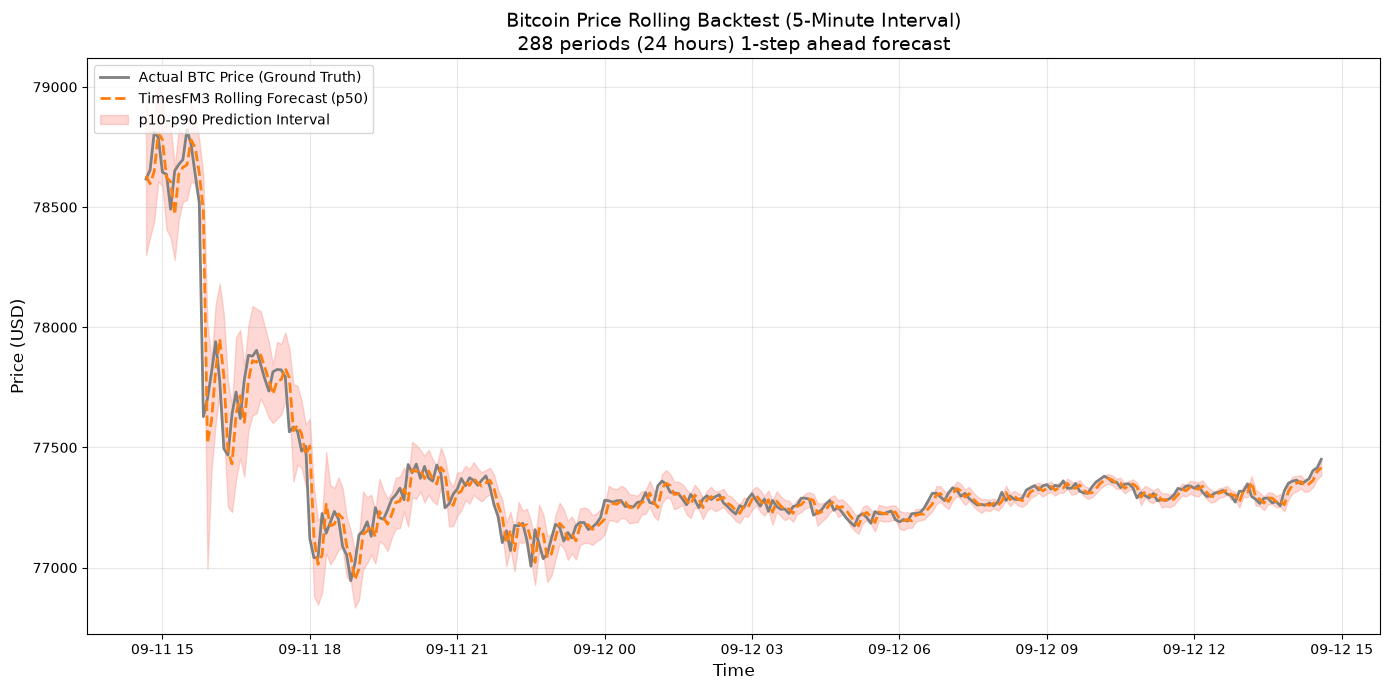

In [5]:
plt.figure(figsize=(14, 7))

plt.plot(eval_dates, ground_truths, label="Actual BTC Price (Ground Truth)", color="gray", linewidth=2.0)
plt.plot(eval_dates, point_forecasts, label="TimesFM3 Rolling Forecast (p50)", color="#ff7f0e", linestyle="--", linewidth=2.0)

if not np.isnan(p10_forecasts).all():
    plt.fill_between(
        eval_dates,
        p10_forecasts,
        p90_forecasts,
        color="salmon",
        alpha=0.3,
        label="p10-p90 Prediction Interval",
    )

plt.title(f"Bitcoin Price Rolling Backtest (5-Minute Interval)\n{eval_len} periods (24 hours) 1-step ahead forecast", fontsize=14)
plt.ylabel("Price (USD)", fontsize=12)
plt.xlabel("Time", fontsize=12)
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()